<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week5Day4DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Upload and load the dataset

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

In [7]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

./archive.zip
./Sample - Superstore.csv
./.config/gce
./.config/default_configs.db
./.config/active_config
./.config/.last_update_check.json
./.config/.last_survey_prompt.yaml
./.config/.last_opt_in_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/config_sentinel
./.config/configurations/config_default
./.config/logs/2026.06.04/13.32.02.654775.log
./.config/logs/2026.06.04/13.32.18.735754.log
./.config/logs/2026.06.04/13.32.21.210570.log
./.config/logs/2026.06.04/13.31.42.499627.log
./.config/logs/2026.06.04/13.32.38.346437.log
./.config/logs/2026.06.04/13.32.39.344962.log
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv


In [8]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

In [9]:
print(df.head())

print(df.shape)

print(df.columns.tolist())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

Preliminary assessment

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.info()

df.describe()

df.isnull().sum()

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (9994, 21)


### Data Cleaning Decisions

The dataset contains no missing values, so no rows or columns needed to be removed or imputed. Duplicate rows were checked and removed, if present, to prevent sales and profit values from being counted more than once.


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [13]:
import numpy as np

df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    (df["Profit"] / df["Sales"]) * 100,
    np.nan
)

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month-Year"] = df["Order Date"].dt.to_period("M")

In [14]:
print(df[
    [
        "Order Date",
        "Sales",
        "Profit",
        "Profit Margin",
        "Order Year",
        "Order Month",
        "Order Month-Year"
    ]
].head())

print("\nUpdated data types:")
print(df.dtypes)

  Order Date     Sales    Profit  Profit Margin  Order Year  Order Month  \
0 2016-11-08  261.9600   41.9136          16.00        2016           11   
1 2016-11-08  731.9400  219.5820          30.00        2016           11   
2 2016-06-12   14.6200    6.8714          47.00        2016            6   
3 2015-10-11  957.5775 -383.0310         -40.00        2015           10   
4 2015-10-11   22.3680    2.5164          11.25        2015           10   

  Order Month-Year  
0          2016-11  
1          2016-11  
2          2016-06  
3          2015-10  
4          2015-10  

Updated data types:
Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code

## Part 2 – Deep-Dive Exploratory Analysis

### Monthly Sales Trend
This visualization examines monthly sales patterns over time and allows the user to compare overall sales with individual product categories.

In [15]:
# Prepare monthly sales data
monthly_sales = (
    df.groupby(["Order Month-Year", "Category"])["Sales"]
      .sum()
      .reset_index()
)

# Convert the monthly period into a timestamp for plotting
monthly_sales["Date"] = monthly_sales["Order Month-Year"].dt.to_timestamp()

In [16]:
def plot_monthly_sales(category="All"):
    plt.figure(figsize=(12, 6))

    if category == "All":
        total_monthly = (
            df.groupby("Order Month-Year")["Sales"]
              .sum()
              .sort_index()
        )

        plt.plot(
            total_monthly.index.to_timestamp(),
            total_monthly.values,
            marker="o",
            linewidth=2,
            markersize=4
        )

        plt.title(
            "Monthly Sales Trend – All Categories",
            fontsize=16,
            fontweight="bold"
        )

    else:
        category_data = monthly_sales[
            monthly_sales["Category"] == category
        ].sort_values("Date")

        plt.plot(
            category_data["Date"],
            category_data["Sales"],
            marker="o",
            linewidth=2,
            markersize=4
        )

        plt.title(
            f"Monthly Sales Trend – {category}",
            fontsize=16,
            fontweight="bold"
        )

    plt.xlabel("Order Date", fontsize=12)
    plt.ylabel("Total Sales ($)", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
categories = ["All"] + sorted(df["Category"].unique().tolist())

category_dropdown = Dropdown(
    options=categories,
    value="All",
    description="Category:"
)

interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

### Initial Observations

Monthly sales fluctuate considerably throughout the dataset. Several months show clear sales peaks, suggesting possible seasonal purchasing patterns. The category dropdown helps determine whether these changes are driven by the overall business or by specific product categories.

## Geographic Sales Performance

This visualization identifies the states generating the highest sales revenue. The interactive slider allows the user to display the Top N states and compare regional sales performance.

In [18]:
# Calculate total sales by state
state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values()
)

In [19]:
def plot_top_states(top_n=10):

    plt.figure(figsize=(12, max(6, top_n * 0.45)))

    top_states = state_sales.tail(top_n)

    plt.barh(
        top_states.index,
        top_states.values
    )

    plt.title(
        f"Top {top_n} States by Sales",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Total Sales ($)")
    plt.ylabel("State")

    # Add labels to each bar
    for i, value in enumerate(top_states.values):
        plt.text(
            value + top_states.max()*0.01,
            i,
            f"${value:,.0f}",
            va="center"
        )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"States displayed: {top_n}")
    print(f"Combined Sales: ${top_states.sum():,.2f}")

In [20]:
top_slider = IntSlider(
    value=10,
    min=5,
    max=25,
    step=1,
    description="Top States:"
)

interact(plot_top_states, top_n=top_slider);

interactive(children=(IntSlider(value=10, description='Top States:', max=25, min=5), Output()), _dom_classes=(…

### Geographic Analysis

The visualization highlights the highest-performing states based on total sales revenue. Adjusting the slider makes it easy to compare how much of the company's revenue comes from a small number of states versus a broader geographic distribution. This helps identify key markets where the company generates the majority of its sales.

## Part 4 – Communicating Insights with Seaborn

### Top 10 Most Profitable Products

This chart identifies the ten products that generated the highest total profit. A horizontal bar chart is used because product names are long and easier to read in this format.

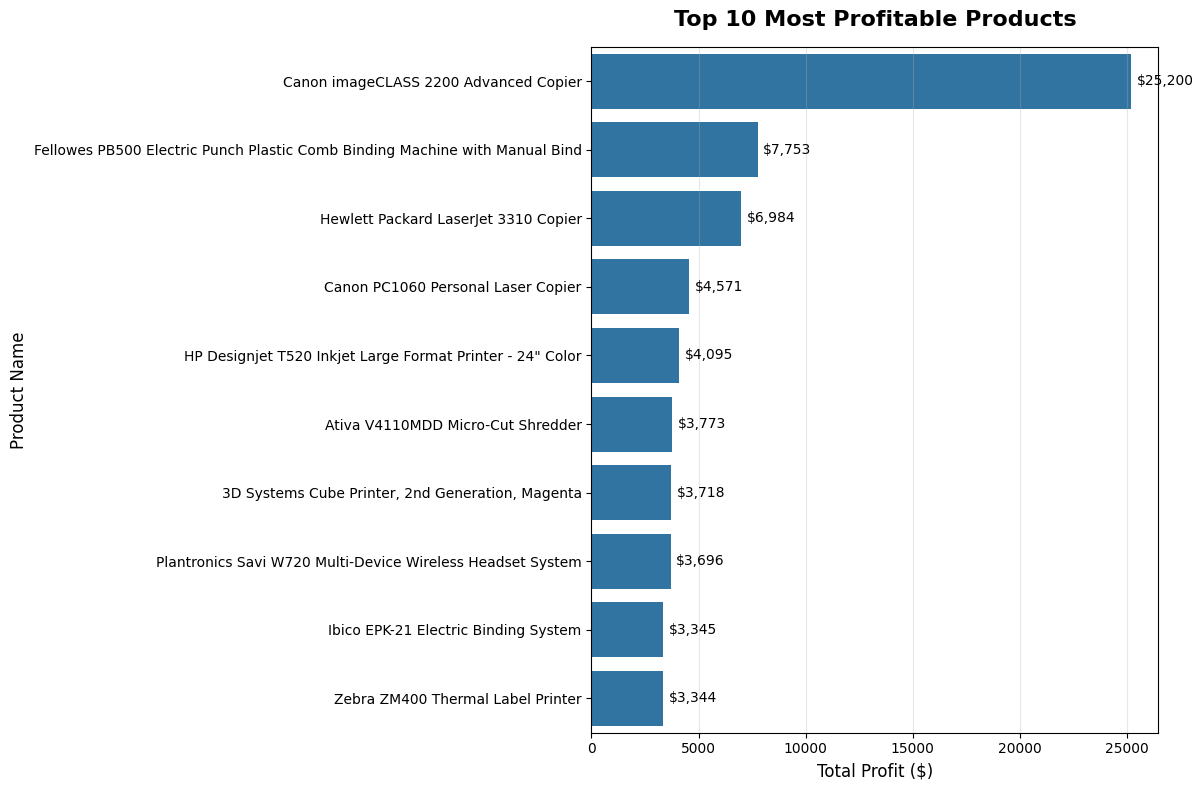

In [21]:
# Calculate total profit by product
product_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Create the chart
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=product_profit.values,
    y=product_profit.index,
    orient="h"
)

plt.title(
    "Top 10 Most Profitable Products",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Profit ($)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

# Add exact profit values
for i, profit in enumerate(product_profit.values):
    ax.text(
        profit + product_profit.max() * 0.01,
        i,
        f"${profit:,.0f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print("Top Product:", product_profit.index[0])
print(f"Highest Product Profit: ${product_profit.iloc[0]:,.2f}")
print(f"Combined Profit of Top 10 Products: ${product_profit.sum():,.2f}")
print(f"Average Profit per Top Product: ${product_profit.mean():,.2f}")

Top Product: Canon imageCLASS 2200 Advanced Copier
Highest Product Profit: $25,199.93
Combined Profit of Top 10 Products: $66,478.78
Average Profit per Top Product: $6,647.88


### Product Profitability Insights

The chart shows that a relatively small group of products contributes a substantial amount of total profit. These high-performing products may deserve additional marketing support, stronger inventory availability, and greater visibility in future sales campaigns.

### Discount vs. Profit

This scatter plot examines the relationship between discount levels and profitability. Product categories are shown separately to reveal whether discounting affects each category differently.

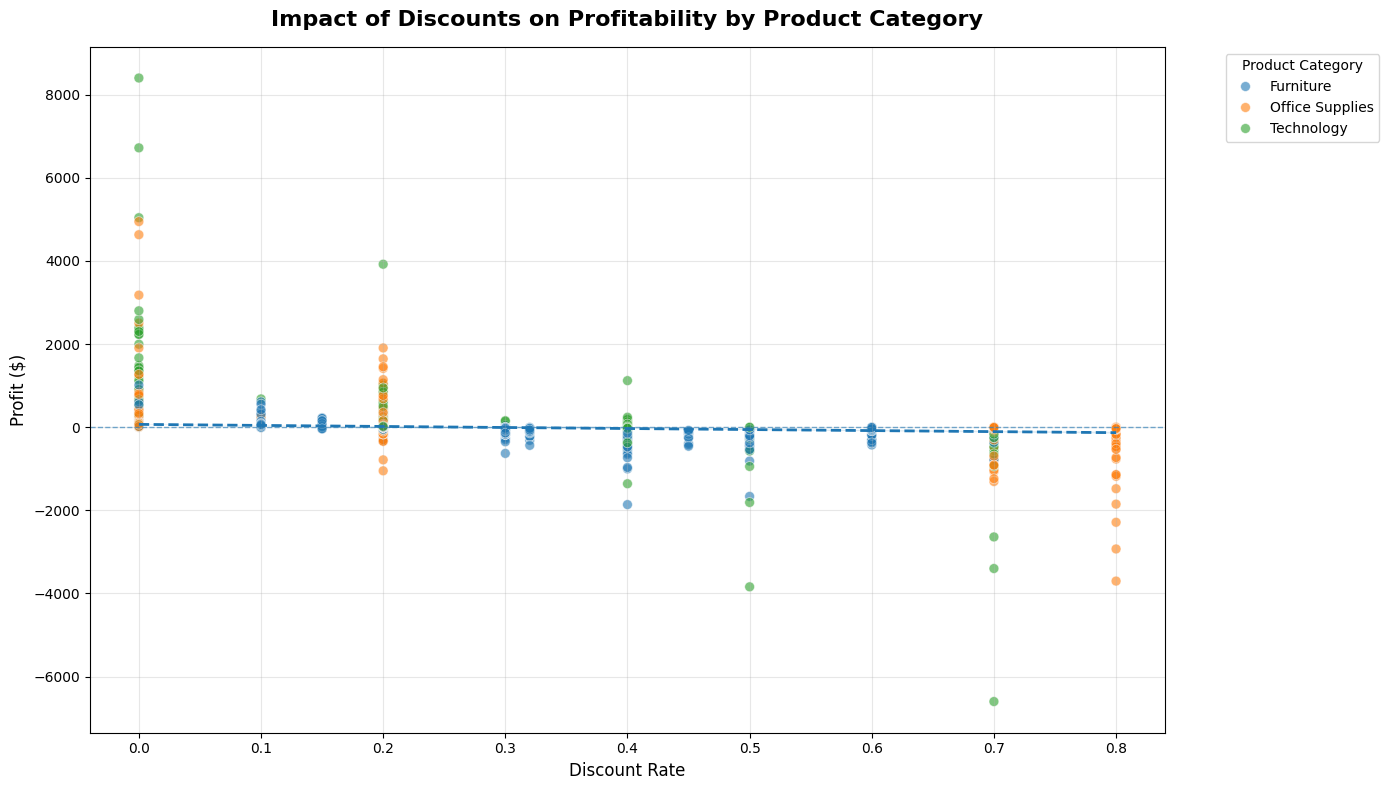

In [23]:
plt.figure(figsize=(14, 8))

# Scatter plot by category
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6,
    s=50
)

# Overall regression trend line
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter=False,
    line_kws={
        "linewidth": 2,
        "linestyle": "--"
    }
)

# Break-even line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

plt.title(
    "Impact of Discounts on Profitability by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Discount Rate", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)

plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
high_discount = df[df["Discount"] > 0.20]

print("Discount Analysis")
print("-----------------")
print(f"Transactions above 20% discount: {len(high_discount):,}")
print(f"Average profit above 20% discount: ${high_discount['Profit'].mean():,.2f}")

loss_rate = (high_discount["Profit"] < 0).mean() * 100

print(f"Loss rate above 20% discount: {loss_rate:.1f}%")

Discount Analysis
-----------------
Transactions above 20% discount: 1,393
Average profit above 20% discount: $-97.18
Loss rate above 20% discount: 96.8%


In [25]:
print("\nCategory-Level Discount Analysis")
print("--------------------------------")

for category in sorted(df["Category"].unique()):
    category_data = df[
        (df["Category"] == category) &
        (df["Discount"] > 0.20)
    ]

    if len(category_data) > 0:
        average_profit = category_data["Profit"].mean()
        category_loss_rate = (
            category_data["Profit"] < 0
        ).mean() * 100

        print(
            f"{category}: "
            f"Average Profit = ${average_profit:,.2f}, "
            f"Loss Rate = {category_loss_rate:.1f}%"
        )


Category-Level Discount Analysis
--------------------------------
Furniture: Average Profit = $-100.51, Loss Rate = 97.2%
Office Supplies: Average Profit = $-69.32, Loss Rate = 100.0%
Technology: Average Profit = $-197.42, Loss Rate = 82.5%


### Discount Analysis Insights

The scatter plot suggests that profitability generally decreases as discount levels rise. Transactions with discounts above 20% should be examined closely because they may have a higher likelihood of producing losses. The category-level results help determine whether certain product categories are more sensitive to discounting than others.

## Part 5 – Methodology and Tooling Review

### Matplotlib vs. Seaborn

Both Matplotlib and Seaborn were used throughout this analysis because each library has unique strengths. Matplotlib provides greater control over plot customization and works well with interactive widgets, while Seaborn simplifies the creation of attractive statistical graphics.

In [26]:
import time

print("=" * 50)
print("MATPLOTLIB VS. SEABORN")
print("=" * 50)

print("\nMatplotlib Strengths")
print("--------------------")
print("• Excellent customization")
print("• Interactive widget support")
print("• Precise control over figures")
print("• Great for dashboards")

print("\nSeaborn Strengths")
print("-----------------")
print("• Attractive default styling")
print("• Built-in statistical plots")
print("• Easy categorical visualizations")
print("• Publication-ready graphics")

# Timing comparison
start = time.time()

plt.figure(figsize=(6,4))
plt.plot(df.groupby("Order Year")["Sales"].sum())
plt.close()

matplotlib_time = time.time() - start

start = time.time()

plt.figure(figsize=(6,4))
sns.lineplot(
    data=df.groupby("Order Year")["Sales"].sum().reset_index(),
    x="Order Year",
    y="Sales"
)
plt.close()

seaborn_time = time.time() - start

print("\nPerformance Comparison")
print("----------------------")
print(f"Matplotlib: {matplotlib_time:.4f} seconds")
print(f"Seaborn:    {seaborn_time:.4f} seconds")

MATPLOTLIB VS. SEABORN

Matplotlib Strengths
--------------------
• Excellent customization
• Interactive widget support
• Precise control over figures
• Great for dashboards

Seaborn Strengths
-----------------
• Attractive default styling
• Built-in statistical plots
• Easy categorical visualizations
• Publication-ready graphics

Performance Comparison
----------------------
Matplotlib: 0.0142 seconds
Seaborn:    0.1476 seconds


### Recommendation

For exploratory analysis and interactive dashboards, Matplotlib is the better choice because it offers greater flexibility and integrates well with ipywidgets.

For executive presentations and business reports, Seaborn is preferred because it produces cleaner visualizations with minimal code and includes useful statistical plotting functions.

Part 6 – Executive Summary

In [27]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales * 100

print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")

top_state = state_sales.idxmax()
top_state_sales = state_sales.max()

print(f"\nHighest Sales State: {top_state}")
print(f"Sales: ${top_state_sales:,.2f}")

top_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .idxmax()
)

print(f"\nTop Sales Category: {top_category}")

loss_rate = (
    (df[df["Discount"] > 0.20]["Profit"] < 0)
    .mean() * 100
)

print(f"\nLoss Rate for Discounts Above 20%: {loss_rate:.1f}%")

EXECUTIVE SUMMARY

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%

Highest Sales State: California
Sales: $457,687.63

Top Sales Category: Technology

Loss Rate for Discounts Above 20%: 96.8%


# Executive Summary

## Key Findings

- The Superstore generated approximately $2.3 Million in total sales and approximately $286,000 in total profit
- California generated the highest total sales among all states.
- Technology was the strongest-performing product category.
- The Top 10 products contributed a significant portion of the company's overall profit.
- Transactions with discounts above 20% showed a substantially higher likelihood of generating losses.

## Business Recommendations

1. Continue investing in the highest-performing products and categories.
2. Focus additional marketing efforts on top-performing states.
3. Carefully evaluate discounts above 20% before approval.
4. Monitor profitability by product category to identify underperforming items.
5. Continue using interactive dashboards to support management decision-making.